In [1]:
import sys
sys.path.append("../../src")
from common_imports import *
from kibble_zurek import state, P_n, P_n_correlations, sigma_general
from equilibrium_critical_correlations import P_n as P0
from equilibrium_critical_correlations import P_n_correlations as P0PR
from equilibrium_critical_correlations import sigma_general as s0

In [2]:
L = 256
taus = np.logspace(-2,2.5,20)
states = [state(L,tau,0) for tau in taus]

/Users/kristianmunnikhuis/Desktop/subsystem_loschmidt_echo/scripts/Compare_Z_X_projectors/../../src/kibble_zurek.py:172: ComplexWarning: Casting complex values to real discards the imaginary part
  C[nx,ny] = D(Nd,state)


[]

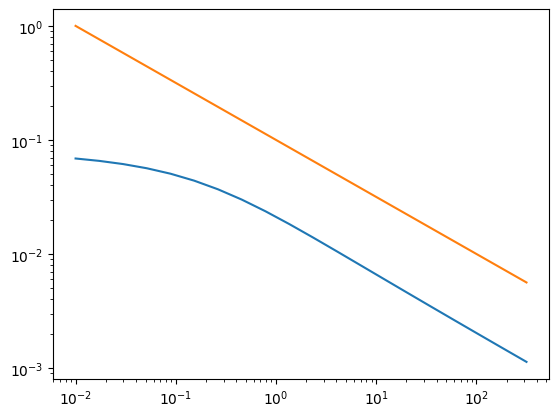

In [79]:
n = 2
delta=[]
for s in states:
    x= P_n(2,s)
    delta.append(abs(x-P0(2))/2)
delta = array(delta)



plot(taus,delta)
plot(taus,taus**(-1/2)/10)
loglog()

In [80]:
r= np.arange(1,150)
data=[]
for s in tqdm(states):
    data_i = [P_n_correlations(2,i,s) for i in tqdm(r)]
    data.append(array(data_i))

  0%|          | 0/20 [00:00<?, ?it/s]/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/numpy/linalg/_linalg.py:2383: RuntimeWarning: divide by zero encountered in det
  r = _umath_linalg.det(a, signature=signature)
/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/numpy/linalg/_linalg.py:2383: RuntimeWarning: overflow encountered in det
  r = _umath_linalg.det(a, signature=signature)
/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/numpy/linalg/_linalg.py:2383: RuntimeWarning: invalid value encountered in det
  r = _umath_linalg.det(a, signature=signature)
 70%|███████   | 14/20 [06:57<02:58, 29.81s/it]


KeyboardInterrupt: 

[]

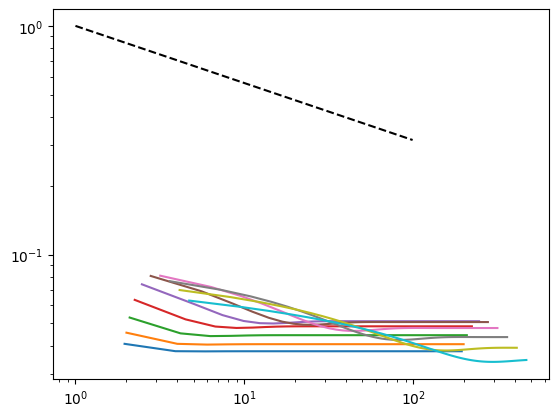

In [77]:
for i in range(len(data)):
    d= data[i]
    t = taus[i]
    dl = delta[i]
    plot(r/dl**(1/4),abs(d)*dl**(1/4),label=t)
plot(r,r**(-1/4),"--k")
#legend()
loglog()

In [81]:
def xi(s):
    rho = 1/2 - sigma_general([0,1],s)/2
    return 1/rho




In [89]:
data=[]
data2=[]
for s in states:
    data.append(xi(s)*10)
    data2.append(int(xi(s)*10))
data=array(data)

/Users/kristianmunnikhuis/Desktop/subsystem_loschmidt_echo/scripts/Compare_Z_X_projectors/../../src/kibble_zurek.py:172: ComplexWarning: Casting complex values to real discards the imaginary part
  C[nx,ny] = D(Nd,state)


In [110]:
def cc(n,l,s):
    x=P_n_correlations(n,l,s)
    y= P_n(n,s)**2
    return x-y
def universal(n,states):
    data=[]
    xis=[]
    for s in tqdm(states):
        lq = 10*xi(s)
        x=cc(n,int(lq),s)/(lq**(1/4))
        xis.append(lq)
        data.append(x)
    return data,xis

        

In [113]:
 x= universal(4,states)

100%|██████████| 20/20 [00:14<00:00,  1.35it/s]


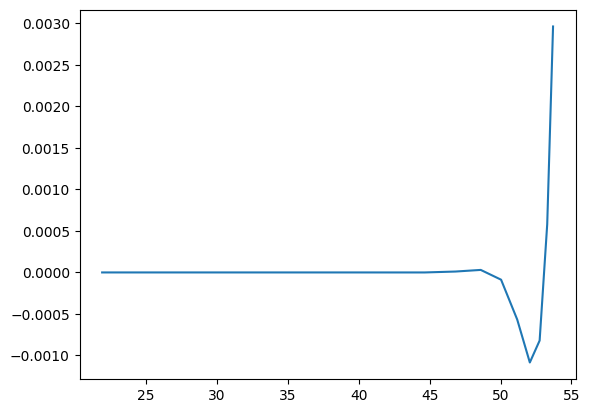

In [114]:
plot(x[1],x[0])